In [1]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger
from PIL import Image
import seaborn as sns
import json
import tqdm
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

2026-04-30 19:50:20.186953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<h1>Analyzing the dataset</h1>

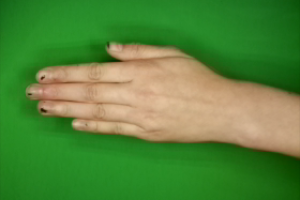

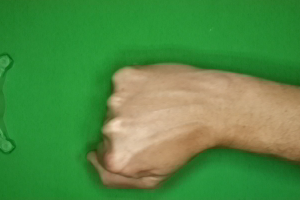

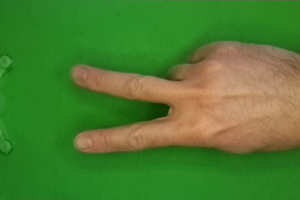

In [2]:
paper= Image.open('./train/paper/2IOsxsG8AaxntdJM.png')
paper.show()
rock= Image.open('./train/rock/2DdERUV7Te8ivywq.png')
rock.show()
scissors= Image.open('./train/scissors/2DEYFsJ27UgVqv3W.png')
scissors.show()


In [3]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.


I0000 00:00:1777571423.479498  475379 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:07:00.0, compute capability: 8.6


Found 2188 files belonging to 3 classes.
Using 656 files for validation.


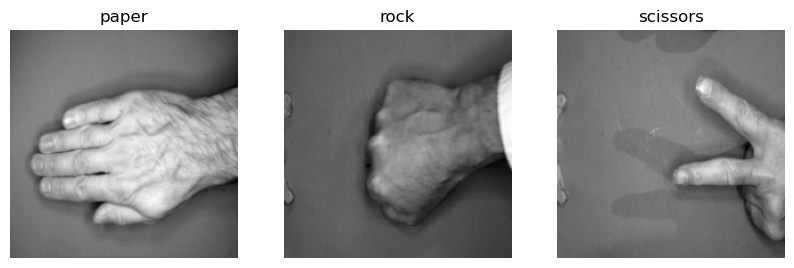

In [4]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

<h2>Model 1 architecture and training</h2>

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

In [6]:

if os.path.exists("model_1.keras"):
    model_1 = keras.models.load_model("model_1.keras")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_1])
    history_1=history_1.history

/home/loren/miniconda3/envs/StatML/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

13/48 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2962 - loss: 3.2220

I0000 00:00:1777571429.195338  475480 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3209 - loss: 2.2601

2026-04-30 19:50:27.733798: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_317', 20 bytes spill stores, 20 bytes spill loads



48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3446 - loss: 1.5520 - val_accuracy: 0.5000 - val_loss: 1.0548
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4687 - loss: 1.0381 - val_accuracy: 0.5188 - val_loss: 0.9856
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5320 - loss: 0.9563 - val_accuracy: 0.6031 - val_loss: 0.9025
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6188 - loss: 0.8628 - val_accuracy: 0.5844 - val_loss: 0.8831
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6599 - loss: 0.7973 - val_accuracy: 0.6187 - val_loss: 0.8115
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7337 - loss: 0.7339 - val_accuracy: 0.6594 - val_loss: 0.8406
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7728 - loss: 0.6612 - val_accuracy: 0.7688 - val_loss: 0.6503
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8035 - loss: 0.5889 - val_accuracy: 0.6969 - val_loss: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


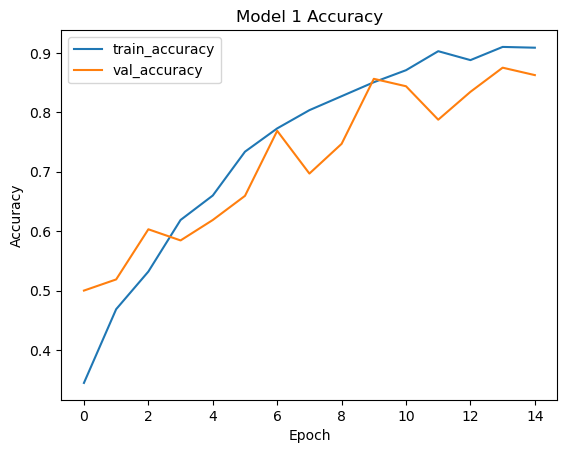

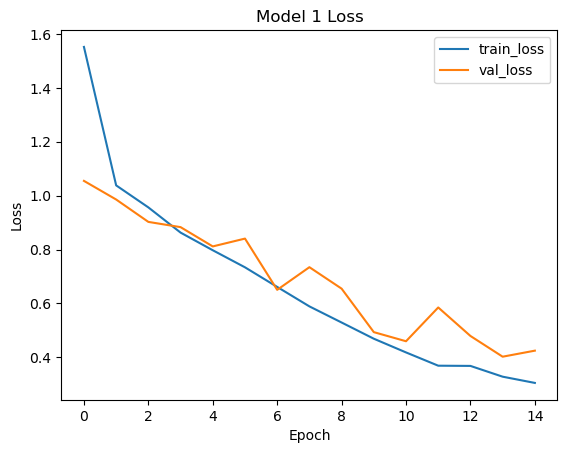

In [7]:
print(history_1.keys())
plt.title("Model 1 Accuracy")
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.title("Model 1 Loss")
plt.plot(history_1["loss"], label="train_loss")
plt.plot(history_1["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 1 prediction</h3> 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
Predicted label: paper
Actual label: paper


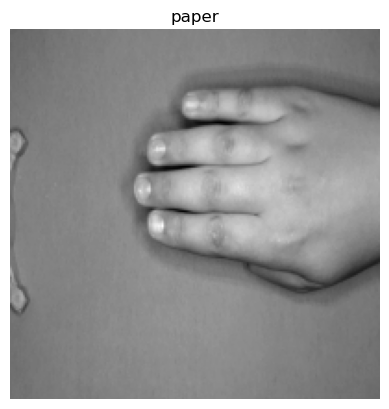

2026-04-30 19:50:46.528689: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 2 architecture and training</h2>

In [9]:

if os.path.exists("model_2.keras"):
    model_2 = keras.models.load_model("model_2.keras")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_2])
    history_2=history_2.history

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.4138 - loss: 3.9581 - val_accuracy: 0.4062 - val_loss: 0.9388
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6691 - loss: 0.7862 - val_accuracy: 0.8188 - val_loss: 0.5351
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7467 - loss: 0.6021 - val_accuracy: 0.9062 - val_loss: 0.3191
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7911 - loss: 0.5489 - val_accuracy: 0.9187 - val_loss: 0.3320
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -27373us/step - accuracy: 0.8342 - loss: 0.4584 - val_accuracy: 0.8750 - val_loss: 0.4403
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8401 - loss: 0.4319 - val_accuracy: 0.9031 - val_loss: 0.3115
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8603 - loss: 0.3776 - val_accuracy: 0.9469 - val_loss: 0.1923
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8916 - loss: 0.3247 - val_accuracy: 0.900

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


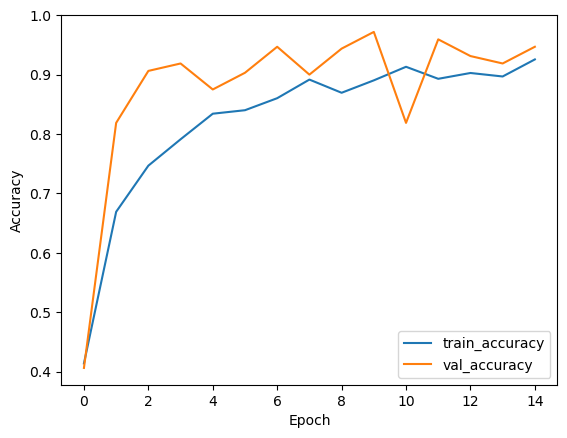

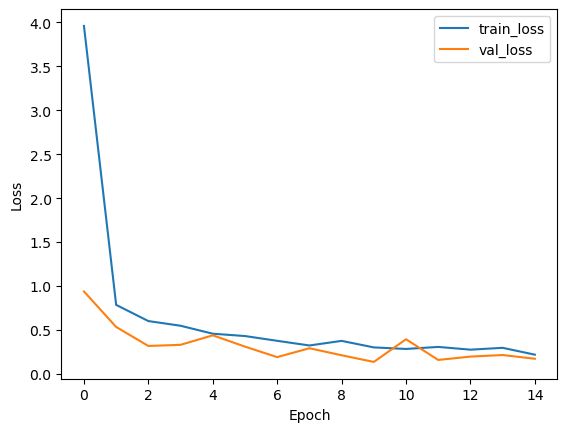

In [10]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_2["loss"], label="train_loss")
plt.plot(history_2["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 2 prediction </h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted label: rock
Actual label: rock


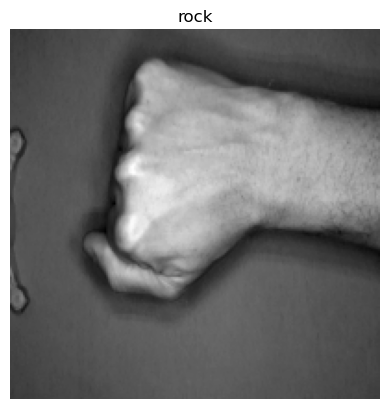

2026-04-30 19:51:14.720739: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_2.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 3 architecture and training</h2>

<h3>Finding The best learning rate using cross-validation</h3>

In [12]:

if os.path.exists("best_lr.json"):
    best_params = json.load(open('best_lr.json', 'r'))
    best_lr = best_params['best_lr']
    best_val_acc = best_params['best_val_acc']
else:
    lr_arr=[1e-5,2e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
    best_val_acc = 0
    best_lr = None
    for lr in lr_arr:
        model_4 = keras.Sequential([
            data_augmentation,
            layers.Rescaling(1./255),

            layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
            layers.MaxPooling2D((2, 2)), 

            layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),


            layers.Flatten(),
            layers.Dense(1024, activation="relu",name='dense_1',kernel_initializer='he_normal'),
            layers.Dropout(0.2),
            layers.Dense(3, activation='softmax')
        ])

        model_4.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]

        )
        
        history_4=model_4.fit(train_ds, validation_data=val_ds, epochs=15)
        history_4=history_4.history

        # Update best learning rate if current model performs better
        if max(history_4['val_accuracy'])  > best_val_acc:
            best_val_acc = max(history_4['val_accuracy'])
            best_lr = lr
    json.dump({'best_lr': best_lr, 'best_val_acc': best_val_acc}, open('best_lr.json', 'w'))


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.3649 - loss: 1.1915 - val_accuracy: 0.3781 - val_loss: 1.0278
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4863 - loss: 1.0186 - val_accuracy: 0.7469 - val_loss: 0.8801
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5946 - loss: 0.9025 - val_accuracy: 0.6406 - val_loss: 0.8331
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6651 - loss: 0.8081 - val_accuracy: 0.8000 - val_loss: 0.6836
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7115 - loss: 0.7345 - val_accuracy: 0.7906 - val_loss: 0.6352
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -21785us/step - accuracy: 0.7383 - loss: 0.6658 - val_accuracy: 0.8719 - val_loss: 0.5202
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7689 - loss: 0.6244 - val_accuracy: 0.8594 - val_loss: 0.5011
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8159 - loss: 0.5435 - val_accuracy: 0.918

In [13]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    mode='max',
    patience=3,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


ckpt = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [14]:
if os.path.exists("model_3.keras"):
    model_3 = keras.models.load_model("model_3.keras")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 

        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
       

        layers.Flatten(),
        layers.Dense(512, activation="relu",name='dense_1',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_3, early_stop, lr_sched, ckpt])
    history_3=history_3.history

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,497,091 (51.49 MB)

 Trainable params: 13,497,091 (51.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4230 - loss: 1.5788 - val_accuracy: 0.5594 - val_loss: 0.7790 - learning_rate: 0.0010
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6286 - loss: 0.7841 - val_accuracy: 0.6313 - val_loss: 0.7310 - learning_rate: 0.0010
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6880 - loss: 0.6686 - val_accuracy: 0.8531 - val_loss: 0.5260 - learning_rate: 0.0010
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7852 - loss: 0.5162 - val_accuracy: 0.9344 - val_loss: 0.2644 - learning_rate: 0.0010
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8708 - loss: 0.3668 - val_accuracy: 0.9656 - val_loss: 0.1327 - learning_rate: 0.0010
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8871 - loss: 0.3189 - val_accuracy: 0.9344 - val_loss: 0.1902 - learning_rate: 0.0010
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9132 - loss: 0.2361 - val_acc

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


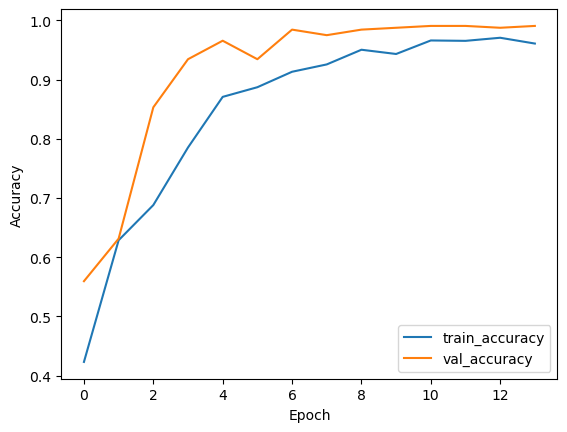

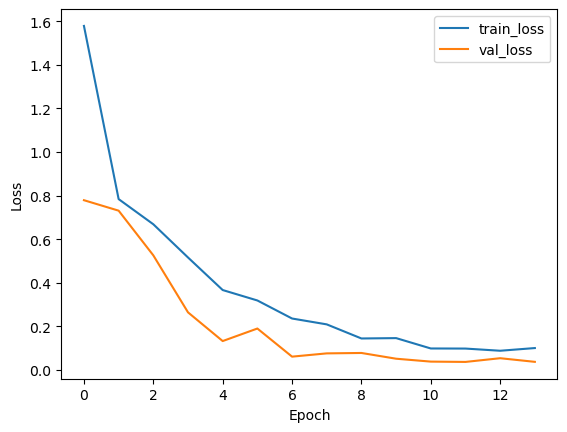

In [15]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_3["loss"], label="train_loss")
plt.plot(history_3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 3 prediction</h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted label: paper
Actual label: paper


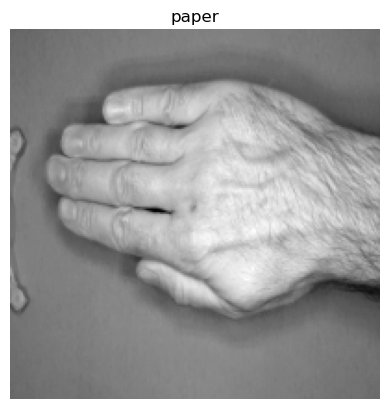

In [16]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

<h2>Models testing</h2>

In [17]:
y_test=[]
img_test=[]
y_pred_1=[]
y_pred_2=[]
y_pred_3=[]
for images, labels in test_ds.unbatch():
    y_test.append(labels.numpy())
    img_test.append(images.numpy())
    y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
    y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
    y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_test = np.array(y_test)
img_test = np.array(img_test)
y_pred_1 = np.array(y_pred_1)
y_pred_2 = np.array(y_pred_2)
y_pred_3 = np.array(y_pred_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

2026-04-30 19:56:01.407582: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<h2>Performance evaluation</h2>

In [18]:
result_1=confusion_matrix(y_test, y_pred_1,labels=[0,1,2])

In [19]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 64 out of 336


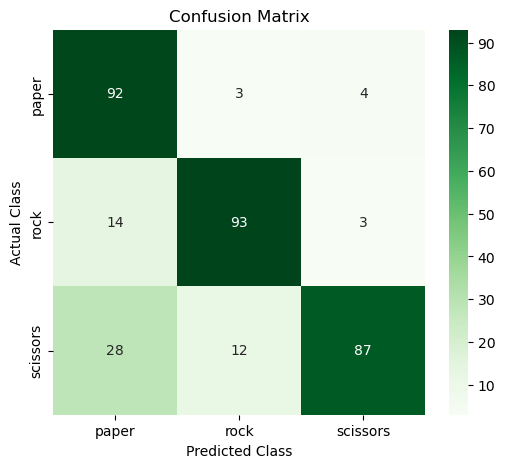

In [20]:
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


In [21]:
result_2=confusion_matrix(y_test, y_pred_2)

In [22]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 17 out of 336


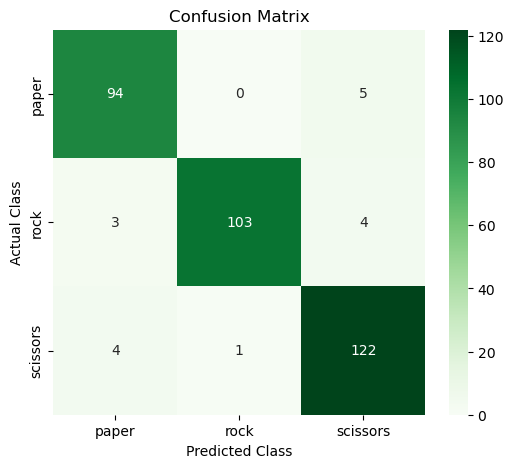

In [23]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_2,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

In [24]:

result_3=confusion_matrix(y_test, y_pred_3)

In [25]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")


Incorrectly classified samples: 4 out of 336


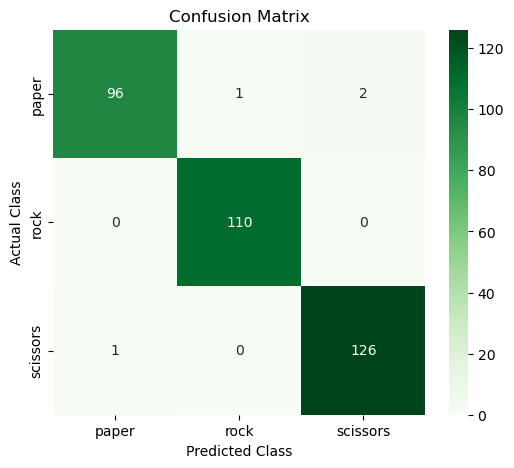

In [26]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_3, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result_3,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_3, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

<h2>Incorrect prediction analisys</h2>

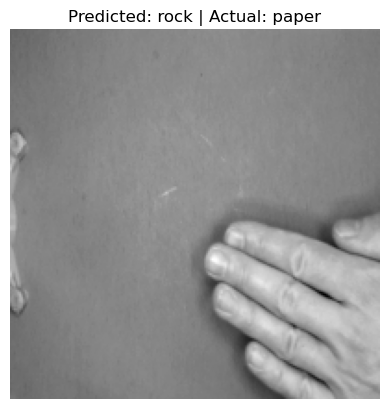

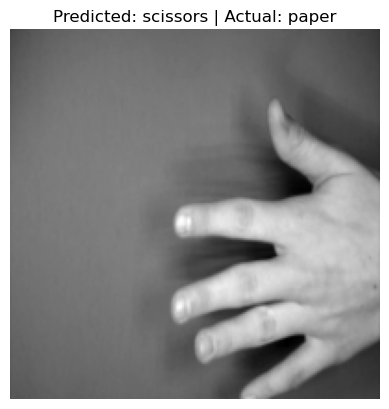

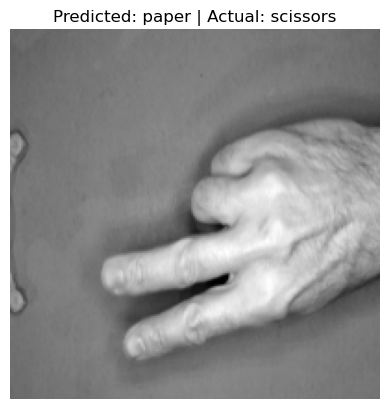

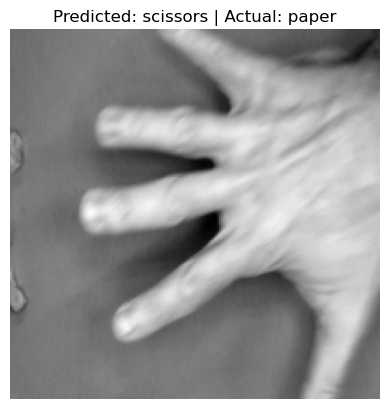

In [27]:
for idx in incorrect_indices_3:
    img=img_test[idx].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(f'Predicted: {class_names[y_pred_3[idx]]} | Actual: {class_names[y_test[idx]]}')
    plt.axis("off")
    plt.show()

<h3>Performance metrics</h3>

In [28]:
m1_true_pos=np.diag(model1_cf)
m1_false_pos=np.sum(model1_cf, axis=0)-m1_true_pos
m1_false_neg=np.sum(model1_cf, axis=1)-m1_true_pos
m1_true_neg=np.sum(model1_cf)-m1_true_pos-m1_false_pos-m1_false_neg

m1_precision =m1_true_pos / (m1_true_pos + m1_false_pos)
m1_recall =m1_true_pos / (m1_true_pos + m1_false_neg)
m1_accuracy = np.sum(m1_true_pos) / np.sum(model1_cf)
m1_f1_score = 2 * (m1_precision * m1_recall) / (m1_precision + m1_recall)




In [29]:
print(f'------------------------model 1 performance metrics------------------------')
print(f'precision = {np.mean(m1_precision)}')
print(f'recall = {np.mean(m1_recall)}')
print(f'accuracy = {m1_accuracy}')
print(f'f1_score = {np.mean(m1_f1_score)}')


------------------------model 1 performance metrics------------------------
precision = 0.8244033967279442
recall = 0.819928948275405
accuracy = 0.8095238095238095
f1_score = 0.8100802989106146


In [30]:
m2_true_pos=np.diag(model2_cf)
m2_false_pos=np.sum(model2_cf, axis=0)-m2_true_pos
m2_false_neg=np.sum(model2_cf, axis=1)-m2_true_pos
m2_true_neg=np.sum(model2_cf)-m2_true_pos-m2_false_pos-m2_false_neg


m2_precision =m2_true_pos / (m2_true_pos + m2_false_pos)
m2_recall =m2_true_pos / (m2_true_pos + m2_false_neg)
m2_accuracy = np.sum(m2_true_pos) / np.sum(model2_cf)
m2_f1_score = 2 * (m2_precision * m2_recall) / (m2_precision + m2_recall)




In [31]:
print(f'------------------------model 2 performance metrics------------------------')
print(f'precision = {np.mean(m2_precision)}')
print(f'recall = {np.mean(m2_recall)}')
print(f'accuracy = {m2_accuracy}')
print(f'f1_score = {np.mean(m2_f1_score)}')


------------------------model 2 performance metrics------------------------
precision = 0.9507917982050701
recall = 0.9488295023728095
accuracy = 0.9494047619047619
f1_score = 0.9494510855128112


In [32]:
m3_true_pos=np.diag(model3_cf)
m3_false_pos=np.sum(model3_cf, axis=0)-m3_true_pos
m3_false_neg=np.sum(model3_cf, axis=1)-m3_true_pos
m3_true_neg=np.sum(model3_cf)-m3_true_pos-m3_false_pos-m3_false_neg


m3_precision =m3_true_pos / (m3_true_pos + m3_false_pos)
m3_recall =m3_true_pos / (m3_true_pos + m3_false_neg)
m3_accuracy = np.sum(m3_true_pos) / np.sum(model3_cf)
m3_f1_score = 2 * (m3_precision * m3_recall) / (m3_precision + m3_recall)




In [33]:
print(f'------------------------model 3 performance metrics------------------------')
print(f'precision = {np.mean(m3_precision)}')
print(f'recall = {np.mean(m3_recall)}')
print(f'accuracy = {m3_accuracy}')
print(f'f1_score = {np.mean(m3_f1_score)}')

------------------------model 3 performance metrics------------------------
precision = 0.9883522375468252
recall = 0.9872743179829794
accuracy = 0.9880952380952381
f1_score = 0.9877674146581709


In [34]:

if not os.path.exists("model_1.keras"):
        model_1.save("model_1.keras")
if not os.path.exists("model_2.keras"):
        model_2.save("model_2.keras")
if not os.path.exists("model_3.keras"):
        model_3.save("model_3.keras")